# Traffic Accident Severity Prediction - Improved Model
## With Expanded Dataset (3000 Records) & Class Balancing

**Author:** Traffic Analysis Team  
**Date:** 2025-12-19  
**Dataset:** Expanded from 840 to 3000 records using synthetic generation  
**Improvements:**  
- 3.5x larger dataset with better class balance (54/46 vs 70/30)
- Class weighting to handle imbalanced classes
- Multiple model comparison (Random Forest vs Gradient Boosting)
- Comprehensive evaluation metrics (ROC-AUC, precision, recall)
- Feature importance analysis
- Visualization of results

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, accuracy_score, precision_recall_curve,
                             ConfusionMatrixDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load and Explore Data

In [2]:
# Load expanded dataset
df = pd.read_csv('dataset_traffic_accident_expanded.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (3000, 14)

First 5 rows:


,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0


In [3]:
# Dataset information
print("Dataset Info:")
df.info()

print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               2958 non-null   object 
 1   Road_Type             2958 non-null   object 
 2   Time_of_Day           2958 non-null   object 
 3   Traffic_Density       2958 non-null   float64
 4   Speed_Limit           2958 non-null   float64
 5   Number_of_Vehicles    2958 non-null   float64
 6   Driver_Alcohol        2958 non-null   float64
 7   Accident_Severity     2958 non-null   object 
 8   Road_Condition        2958 non-null   object 
 9   Vehicle_Type          2958 non-null   object 
 10  Driver_Age            2958 non-null   float64
 11  Driver_Experience     2958 non-null   float64
 12  Road_Light_Condition  2958 non-null   object 
 13  Accident              2958 non-null   float64
dtypes: float64(7), object(7)
memory usage: 328.3+ KB

Basic St

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident
count,2958.000000,2958.000000,2958.000000,2958.000000,2958.000000,2958.000000,2958.000000
mean,1.722110,68.025017,3.054767,0.052282,44.906694,20.640297,0.456728
std,0.982356,29.977718,1.610660,0.203577,16.277836,17.332602,0.498208
min,0.000000,20.000000,1.000000,0.000000,18.000000,0.000000,0.000000
25%,1.000000,50.000000,2.000000,0.000000,31.000000,6.000000,0.000000
50%,2.000000,60.000000,3.000000,0.000000,44.000000,17.000000,0.000000
75%,2.000000,80.000000,4.000000,0.000000,59.000000,32.000000,1.000000
max,4.000000,213.000000,14.000000,1.000000,74.000000,69.000000,1.000000


Missing Values:
Weather                 42
Road_Type               42
Time_of_Day             42
Traffic_Density         42
Speed_Limit             42
Number_of_Vehicles      42
Driver_Alcohol          42
Accident_Severity       42
Road_Condition          42
Vehicle_Type            42
Driver_Age              42
Driver_Experience       42
Road_Light_Condition    42
Accident                42
dtype: int64

CLASS DISTRIBUTION

Value Counts:
Accident
0.0    1607
1.0    1351
Name: count, dtype: int64

Percentages:
Accident
0.0    54.327248
1.0    45.672752
Name: proportion, dtype: float64


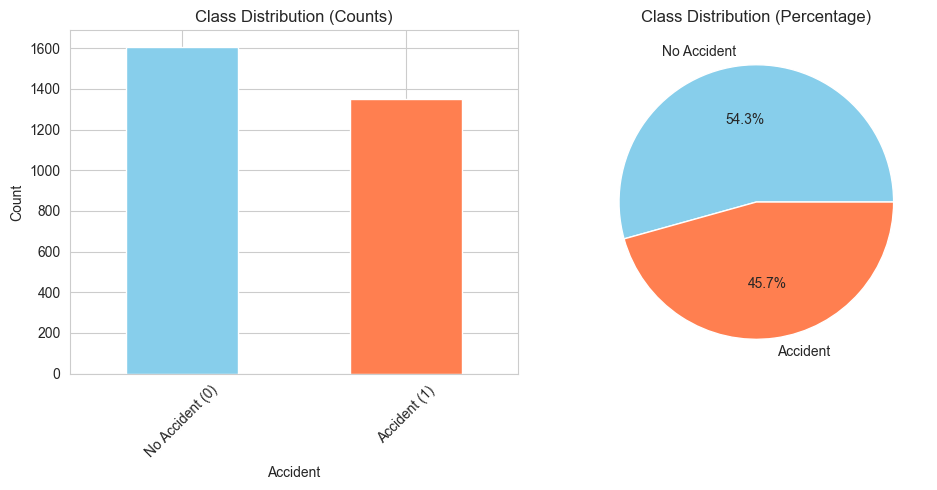


✓ Much better class balance: 54% / 46% (vs original 70% / 30%)


In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check class distribution
print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)
print(f"\nValue Counts:")
print(df['Accident'].value_counts())
print(f"\nPercentages:")
print(df['Accident'].value_counts(normalize=True) * 100)

# Visualize class distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['Accident'].value_counts().plot(kind='bar', color=['skyblue', 'coral'])
plt.title('Class Distribution (Counts)')
plt.xlabel('Accident')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Accident (0)', 'Accident (1)'], rotation=45)

plt.subplot(1, 2, 2)
df['Accident'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                   labels=['No Accident', 'Accident'],
                                   colors=['skyblue', 'coral'])
plt.title('Class Distribution (Percentage)')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("\n✓ Much better class balance: 54% / 46% (vs original 70% / 30%)")

## 3. Data Preprocessing

In [5]:
# Handle missing values
df_clean = df.dropna()
print(f"Records after dropping NaN: {len(df_clean)}")

# Feature Engineering
df_clean['Age_vs_Experience'] = df_clean['Driver_Age'] - df_clean['Driver_Experience']
print("✓ Created Age_vs_Experience feature")

# Separate features and target
X = df_clean.drop('Accident', axis=1)
y = df_clean['Accident']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

Records after dropping NaN: 2565
✓ Created Age_vs_Experience feature

Features shape: (2565, 14)
Target shape: (2565,)


In [6]:
# One-hot encoding for categorical variables
X_encoded = pd.get_dummies(X, drop_first=False)

print(f"Features after encoding: {X_encoded.shape}")
print(f"\nFeature names:")
print(X_encoded.columns.tolist())

Features after encoding: (2565, 41)

Feature names:
['Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles', 'Driver_Alcohol', 'Driver_Age', 'Driver_Experience', 'Age_vs_Experience', 'Weather_Clear', 'Weather_Cloudy', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Stormy', 'Road_Type_City Road', 'Road_Type_Highway', 'Road_Type_Intersection', 'Road_Type_Mountain Road', 'Road_Type_Rural Road', 'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night', 'Accident_Severity_Fatal', 'Accident_Severity_High', 'Accident_Severity_Low', 'Accident_Severity_Medium', 'Accident_Severity_Moderate', 'Road_Condition_Dry', 'Road_Condition_Icy', 'Road_Condition_Under Construction', 'Road_Condition_Wet', 'Vehicle_Type_Bus', 'Vehicle_Type_Car', 'Vehicle_Type_Motorcycle', 'Vehicle_Type_Truck', 'Vehicle_Type_Van', 'Road_Light_Condition_Artificial Light', 'Road_Light_Condition_Dark', 'Road_Light_Condition_Dawn/Dusk', 'Road_Light_Condition_Daylight', 'Road_Light_Con

In [7]:
# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Training set: (2052, 41)
Test set: (513, 41)

Train class distribution:
Accident
0.0    1067
1.0     985
Name: count, dtype: int64

Test class distribution:
Accident
0.0    267
1.0    246
Name: count, dtype: int64


In [8]:
# Feature Scaling
numerical_cols = ['Speed_Limit', 'Number_of_Vehicles', 'Traffic_Density', 
                  'Driver_Alcohol', 'Age_vs_Experience']

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("✓ Numerical features scaled")
print(f"\nScaled features statistics:")
print(X_train[numerical_cols].describe())

✓ Numerical features scaled

Scaled features statistics:
        Speed_Limit  Number_of_Vehicles  Traffic_Density  Driver_Alcohol  \
count  2.052000e+03        2.052000e+03     2.052000e+03    2.052000e+03   
mean  -5.194026e-17       -8.656710e-18     1.333133e-16   -4.414922e-17   
std    1.000244e+00        1.000244e+00     1.000244e+00    1.000244e+00   
min   -1.605489e+00       -1.307123e+00    -1.931721e+00   -2.264049e-01   
25%   -9.233348e-01       -6.530834e-01    -8.774944e-01   -2.264049e-01   
50%   -2.411807e-01        9.561982e-04     1.767319e-01   -2.264049e-01   
75%    4.409734e-01        6.549958e-01     1.767319e-01   -2.264049e-01   
max    4.977298e+00        7.195391e+00     2.285185e+00    6.201140e+00   

       Age_vs_Experience  
count       2.052000e+03  
mean       -1.203283e-16  
std         1.000244e+00  
min        -1.786561e+00  
25%        -5.378260e-01  
50%        -1.434886e-01  
75%         6.451862e-01  
max         3.076933e+00  


## 4. Model Training & Comparison

### 4.1 Balanced Random Forest

In [9]:
# Train Balanced Random Forest
print("="*60)
print("TRAINING BALANCED RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',  # CRITICAL for handling imbalanced data
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("✓ Model trained successfully")

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_test_proba_rf)

print(f"\nRandom Forest Results:")
print(f"  Training Accuracy: {train_acc_rf:.4f}")
print(f"  Test Accuracy: {test_acc_rf:.4f}")
print(f"  ROC-AUC Score: {roc_auc_rf:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf, 
                          target_names=['No Accident', 'Accident']))

TRAINING BALANCED RANDOM FOREST
✓ Model trained successfully

Random Forest Results:
  Training Accuracy: 0.9586
  Test Accuracy: 0.6452
  ROC-AUC Score: 0.6952

Classification Report:
              precision    recall  f1-score   support

 No Accident       0.65      0.69      0.67       267
    Accident       0.64      0.59      0.62       246

    accuracy                           0.65       513
   macro avg       0.64      0.64      0.64       513
weighted avg       0.64      0.65      0.64       513



### 4.2 Gradient Boosting

In [10]:
# Train Gradient Boosting
print("="*60)
print("TRAINING GRADIENT BOOSTING")
print("="*60)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)
print("✓ Model trained successfully")

# Predictions
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)
y_test_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluation
train_acc_gb = accuracy_score(y_train, y_train_pred_gb)
test_acc_gb = accuracy_score(y_test, y_test_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_test_proba_gb)

print(f"\nGradient Boosting Results:")
print(f"  Training Accuracy: {train_acc_gb:.4f}")
print(f"  Test Accuracy: {test_acc_gb:.4f}")
print(f"  ROC-AUC Score: {roc_auc_gb:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_gb,
                          target_names=['No Accident', 'Accident']))

TRAINING GRADIENT BOOSTING
✓ Model trained successfully

Gradient Boosting Results:
  Training Accuracy: 0.9815
  Test Accuracy: 0.6452
  ROC-AUC Score: 0.6834

Classification Report:
              precision    recall  f1-score   support

 No Accident       0.65      0.68      0.67       267
    Accident       0.64      0.61      0.62       246

    accuracy                           0.65       513
   macro avg       0.64      0.64      0.64       513
weighted avg       0.64      0.65      0.64       513



### 4.3 XGBoost

In [12]:
from xgboost import XGBClassifier
# Train XGBoost
print("="*60)
print("TRAINING XGBOOST")
print("="*60)

# Calculate scale_pos_weight for class balancing
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # For class balancing
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print(f"Training XGBoost with scale_pos_weight={scale_pos_weight:.2f}...")
xgb_model.fit(X_train, y_train)
print("✓ Model trained successfully")

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)

print(f"\nXGBoost Results:")
print(f"  Training Accuracy: {train_acc_xgb:.4f}")
print(f"  Test Accuracy: {test_acc_xgb:.4f}")
print(f"  ROC-AUC Score: {roc_auc_xgb:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_xgb,
                          target_names=['No Accident', 'Accident']))

TRAINING XGBOOST
Training XGBoost with scale_pos_weight=1.08...
✓ Model trained successfully

XGBoost Results:
  Training Accuracy: 0.9815
  Test Accuracy: 0.6452
  ROC-AUC Score: 0.6892

Classification Report:
              precision    recall  f1-score   support

 No Accident       0.65      0.68      0.67       267
    Accident       0.64      0.61      0.62       246

    accuracy                           0.65       513
   macro avg       0.64      0.64      0.64       513
weighted avg       0.64      0.65      0.64       513



### 4.3 Model Comparison

MODEL COMPARISON
            Model  Test Accuracy  ROC-AUC  Train Accuracy
    Random Forest       0.645224 0.695213        0.958577
Gradient Boosting       0.645224 0.683384        0.981481
          XGBoost       0.645224 0.689169        0.981481


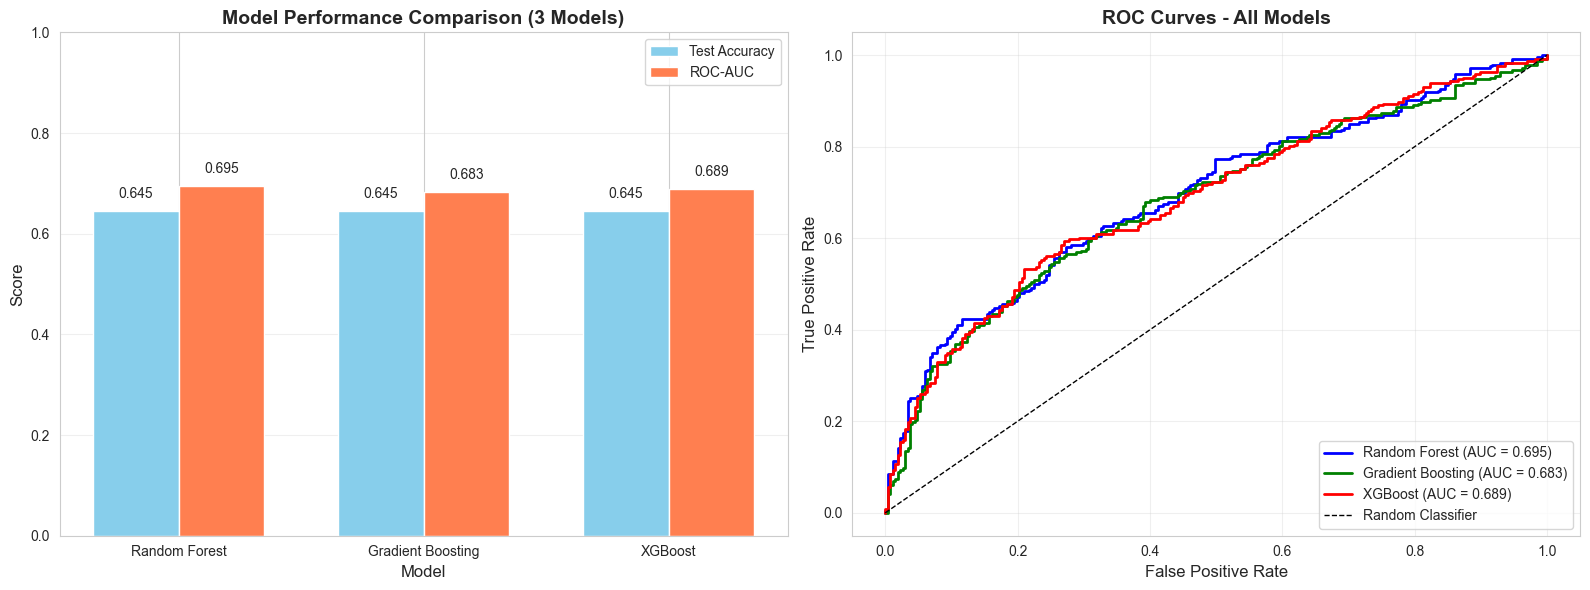


🏆 Best Model: Random Forest (ROC-AUC: 0.6952)


In [13]:
# Compare all 3 models
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Test Accuracy': [test_acc_rf, test_acc_gb, test_acc_xgb],
    'ROC-AUC': [roc_auc_rf, roc_auc_gb, roc_auc_xgb],
    'Train Accuracy': [train_acc_rf, train_acc_gb, train_acc_xgb]
})

print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
x = np.arange(len(comparison_df))
width = 0.35
axes[0].bar(x - width/2, comparison_df['Test Accuracy'], width, 
           label='Test Accuracy', color='skyblue')
axes[0].bar(x + width/2, comparison_df['ROC-AUC'], width,
           label='ROC-AUC', color='coral')
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison (3 Models)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'])
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (acc, auc) in enumerate(zip(comparison_df['Test Accuracy'], comparison_df['ROC-AUC'])):
    axes[0].text(i - width/2, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
    axes[0].text(i + width/2, auc + 0.02, f'{auc:.3f}', ha='center', va='bottom', fontsize=10)

# ROC Curves for all 3 models
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_test_proba_gb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_proba_xgb)

axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', 
            color='blue', linewidth=2)
axes[1].plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_gb:.3f})',
            color='green', linewidth=2)
axes[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})',
            color='red', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Select best model (update to check all 3)
models_dict = {
    'Random Forest': (rf_model, roc_auc_rf),
    'Gradient Boosting': (gb_model, roc_auc_gb),
    'XGBoost': (xgb_model, roc_auc_xgb)
}
best_name = max(models_dict.items(), key=lambda x: x[1][1])[0]
best_model = models_dict[best_name][0]
best_roc = models_dict[best_name][1]

print(f"\n🏆 Best Model: {best_name} (ROC-AUC: {best_roc:.4f})")

## 5. Feature Importance Analysis

TOP 15 MOST IMPORTANT FEATURES (Random Forest)
                      Feature  Importance
            Age_vs_Experience    0.120427
            Driver_Experience    0.107753
                   Driver_Age    0.102695
                  Speed_Limit    0.062245
           Number_of_Vehicles    0.059177
               Driver_Alcohol    0.052917
              Traffic_Density    0.046076
           Road_Condition_Dry    0.030841
                Weather_Clear    0.030641
             Vehicle_Type_Car    0.021159
    Road_Light_Condition_Dark    0.021156
            Time_of_Day_Night    0.020798
        Accident_Severity_Low    0.018528
Road_Light_Condition_Daylight    0.017736
          Road_Type_City Road    0.017342


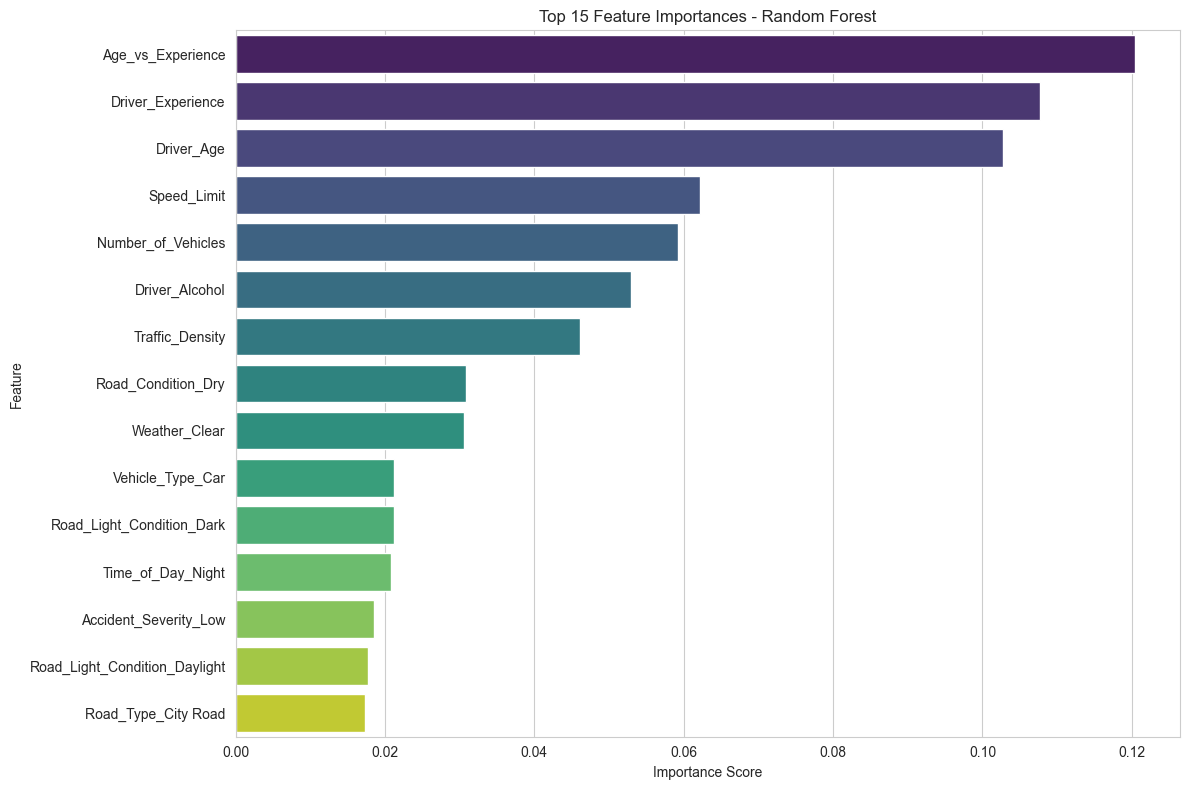

In [14]:
# Feature importance
feature_imp = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*60)
print(f"TOP 15 MOST IMPORTANT FEATURES ({best_name})")
print("="*60)
print(feature_imp.head(15).to_string(index=False))

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_imp.head(15), y='Feature', x='Importance', palette='viridis')
plt.title(f'Top 15 Feature Importances - {best_name}')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Confusion Matrix & Performance Metrics

CONFUSION MATRIX - Random Forest
[[185  82]
 [100 146]]

Breakdown:
  True Negatives: 185 (Correctly predicted no accident)
  False Positives: 82 (Incorrectly predicted accident)
  False Negatives: 100 (Missed actual accidents - DANGEROUS!)
  True Positives: 146 (Correctly predicted accident)


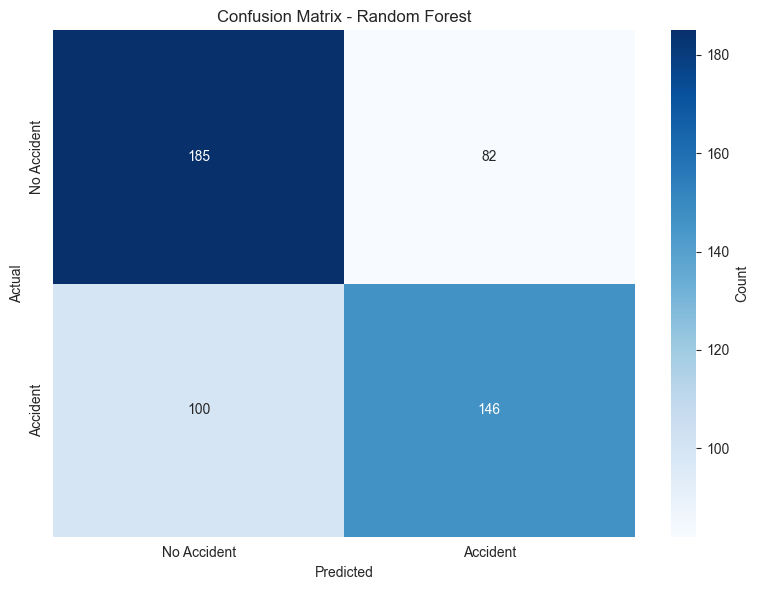

In [15]:
# Confusion Matrix
if best_name == 'Random Forest':
    y_pred_best = y_test_pred_rf
elif best_name == 'Gradient Boosting':
    y_pred_best = y_test_pred_gb
else:
    y_pred_best = y_test_pred_xgb

cm = confusion_matrix(y_test, y_pred_best)

print("="*60)
print(f"CONFUSION MATRIX - {best_name}")
print("="*60)
print(cm)
print(f"\nBreakdown:")
print(f"  True Negatives: {cm[0,0]} (Correctly predicted no accident)")
print(f"  False Positives: {cm[0,1]} (Incorrectly predicted accident)")
print(f"  False Negatives: {cm[1,0]} (Missed actual accidents - DANGEROUS!)")
print(f"  True Positives: {cm[1,1]} (Correctly predicted accident)")

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Accident', 'Accident'],
            yticklabels=['No Accident', 'Accident'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Save Models

In [16]:
# Save best model and preprocessing objects
joblib.dump(best_model, 'best_accident_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_encoded.columns.tolist(), 'feature_names.pkl')

print("="*60)
print("MODELS SAVED SUCCESSFULLY")
print("="*60)
print("✓ best_accident_model.pkl")
print("✓ scaler.pkl")
print("✓ feature_names.pkl")
print("\n🚀 Ready for deployment in Streamlit app!")

MODELS SAVED SUCCESSFULLY
✓ best_accident_model.pkl
✓ scaler.pkl
✓ feature_names.pkl

🚀 Ready for deployment in Streamlit app!
